# Schema validation results viewer

Inspect successful assessments and calculate API spend from recorded token usage. Rerun the **Load results** cell to refresh this notebook while or after the validation pipeline runs.

Costs use [OpenAI's Standard processing prices](https://developers.openai.com/api/docs/pricing) for GPT-5.5 with less than 272K context, retrieved August 25, 2026. Only successful calls in the results JSONL are included.

In [1]:
import json
from collections import Counter
from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import Image, Markdown, display

from data_snapshot.constants import ROOT


## Configuration

In [2]:
RESULTS_PATH = ROOT / "notebooks/schema_validation/outputs/calibration_results.jsonl"
ERRORS_PATH = ROOT / "notebooks/schema_validation/outputs/calibration_errors.jsonl"

# USD per 1 million tokens, context under 272K.
PRICES_USD_PER_1M = {
    ("gpt-5.5", "default"): {
        "input": 5.00,
        "cached_input": 0.50,
        "output": 30.00,
    },
    ("gpt-5.5", "flex"): {
        "input": 2.50,
        "cached_input": 0.25,
        "output": 15.00,
    },
}


In [3]:
def load_jsonl(path: Path) -> list[dict[str, Any]]:
    """Load JSON objects from a JSONL file.

    Parameters
    ----------
    path : Path
        JSONL file to read.

    Returns
    -------
    list[dict[str, Any]]
        Parsed records, or an empty list when the file does not exist.

    Raises
    ------
    ValueError
        If a non-empty line is not valid JSON.
    """
    if not path.exists():
        return []

    records = []
    with path.open(encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            if not line.strip():
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"Invalid JSON in {path} at line {line_number}."
                ) from exc
    return records


def calculate_cost_usd(record: dict[str, Any]) -> float:
    """Calculate one successful call's token cost in US dollars.

    Parameters
    ----------
    record : dict[str, Any]
        Successful validation result containing model and usage data.

    Returns
    -------
    float
        Estimated API cost using the recorded service-tier prices.

    Raises
    ------
    ValueError
        If usage is missing or cached tokens exceed input tokens.
    KeyError
        If pricing is not configured for the model and service tier.
    """
    usage = record.get("usage")
    if not isinstance(usage, dict):
        raise ValueError(f"Missing usage for {record.get('snapshot_file_name')}.")

    raw_response = record.get("raw_response") or {}
    service_tier = raw_response.get("service_tier") or (
        record.get("request_config") or {}
    ).get("service_tier", "default")
    if service_tier == "auto":
        service_tier = "default"

    model = record["model"]
    prices = PRICES_USD_PER_1M[(model, service_tier)]
    input_tokens = int(usage["input_tokens"])
    cached_tokens = int(
        (usage.get("input_tokens_details") or {}).get("cached_tokens", 0)
    )
    output_tokens = int(usage["output_tokens"])
    if cached_tokens > input_tokens:
        raise ValueError("Cached input tokens cannot exceed input tokens.")

    cost = (input_tokens - cached_tokens) * prices["input"]
    cost += cached_tokens * prices["cached_input"]
    cost += output_tokens * prices["output"]
    return cost / 1_000_000


## Load results

In [4]:
results = load_jsonl(RESULTS_PATH)
errors = load_jsonl(ERRORS_PATH)
if not results:
    raise ValueError(f"No successful results found at {RESULTS_PATH}.")

rows = []
for record in results:
    usage = record["usage"]
    parsed = record["parsed_output"]
    fit_counts = Counter(
        observation["fit_status"] for observation in parsed["observations"]
    )
    cached_tokens = (usage.get("input_tokens_details") or {}).get("cached_tokens", 0)
    service_tier = (record.get("raw_response") or {}).get("service_tier") or (
        record.get("request_config") or {}
    ).get("service_tier", "default")
    rows.append(
        {
            "snapshot_file_name": record["snapshot_file_name"],
            "source": record["source"],
            "artifact_type": record["artifact_type"],
            "model": record["model"],
            "service_tier": service_tier,
            "input_tokens": usage["input_tokens"],
            "cached_input_tokens": cached_tokens,
            "output_tokens": usage["output_tokens"],
            "total_tokens": usage["total_tokens"],
            "elapsed_seconds": record["elapsed_seconds"],
            "observations": len(parsed["observations"]),
            "covered": fit_counts["covered"],
            "weak_fit": fit_counts["weak_fit"],
            "no_fit": fit_counts["no_fit"],
            "out_of_scope": fit_counts["out_of_scope"],
            "uncertain": fit_counts["uncertain"],
            "candidate_fields": len(parsed["candidate_new_fields"]),
            "cost_usd": calculate_cost_usd(record),
        }
    )

results_df = (
    pd.DataFrame(rows)
    .sort_values(["source", "artifact_type", "snapshot_file_name"])
    .reset_index(drop=True)
)
records_by_name = {record["snapshot_file_name"]: record for record in results}
successful_files = set(records_by_name)
unresolved_errors = [
    error for error in errors if error.get("snapshot_file_name") not in successful_files
]

print(
    f"Loaded {len(results):,} successful calls, {len(errors):,} error attempts, "
    f"and {len(unresolved_errors):,} unresolved errors."
)


Loaded 12 successful calls, 0 error attempts, and 0 unresolved errors.


## API spend

In [5]:
overall_cost = pd.DataFrame(
    {
        "successful_calls": [len(results_df)],
        "total_api_spend_usd": [results_df["cost_usd"].sum()],
        "average_cost_per_api_call_usd": [results_df["cost_usd"].mean()],
        "total_input_tokens": [results_df["input_tokens"].sum()],
        "total_cached_input_tokens": [
            results_df["cached_input_tokens"].sum()
        ],
        "total_output_tokens": [results_df["output_tokens"].sum()],
    }
)
display(
    overall_cost.style.format(
        {
            "total_api_spend_usd": "${:,.4f}",
            "average_cost_per_api_call_usd": "${:,.4f}",
            "total_input_tokens": "{:,}",
            "total_cached_input_tokens": "{:,}",
            "total_output_tokens": "{:,}",
        }
    ).hide(axis="index")
)


successful_calls,total_api_spend_usd,average_cost_per_api_call_usd,total_input_tokens,total_cached_input_tokens,total_output_tokens
12,$0.9030,$0.0753,"141,883","30,976","41,202"


In [6]:
corpus_costs = (
    results_df.groupby("source", as_index=False)
    .agg(
        successful_calls=("snapshot_file_name", "size"),
        total_api_spend_usd=("cost_usd", "sum"),
        average_cost_per_api_call_usd=("cost_usd", "mean"),
        input_tokens=("input_tokens", "sum"),
        cached_input_tokens=("cached_input_tokens", "sum"),
        output_tokens=("output_tokens", "sum"),
    )
    .sort_values("source")
)
display(
    corpus_costs.style.format(
        {
            "total_api_spend_usd": "${:,.4f}",
            "average_cost_per_api_call_usd": "${:,.4f}",
            "input_tokens": "{:,}",
            "cached_input_tokens": "{:,}",
            "output_tokens": "{:,}",
        }
    ).hide(axis="index")
)


source,successful_calls,total_api_spend_usd,average_cost_per_api_call_usd,input_tokens,cached_input_tokens,output_tokens
prwp,4,$0.2939,$0.0735,"50,530","8,448","12,436"
refugee,4,$0.3343,$0.0836,"60,494","11,264","13,891"
unhcr,4,$0.2749,$0.0687,"30,859","11,264","14,875"


## Results overview

In [7]:
overview_columns = [
    "snapshot_file_name",
    "source",
    "artifact_type",
    "service_tier",
    "observations",
    "covered",
    "weak_fit",
    "no_fit",
    "out_of_scope",
    "uncertain",
    "candidate_fields",
    "cost_usd",
]
display(
    results_df[overview_columns]
    .style.format({"cost_usd": "${:,.4f}"})
    .set_properties(subset=["snapshot_file_name"], **{"text-align": "left"})
)


,snapshot_file_name,source,artifact_type,service_tier,observations,covered,weak_fit,no_fit,out_of_scope,uncertain,candidate_fields,cost_usd
0,document_11225119_figure_000.png,prwp,figure,flex,11,9,1,1,0,0,2,$0.0886
1,document_439628_figure_003.png,prwp,figure,flex,12,9,1,2,0,0,3,$0.0700
2,document_1689472_table_006.png,prwp,table,flex,14,12,1,1,0,0,2,$0.0827
3,document_699863_table_004.png,prwp,table,flex,15,15,0,0,0,0,0,$0.0526
4,161_28046_figure_000.png,refugee,figure,flex,12,9,1,2,0,0,3,$0.0829
5,195_multi-page_figure_001.png,refugee,figure,flex,14,9,1,2,0,2,3,$0.1080
6,020_P1781250bdd2b50b0b9720d5c17632331c_table_007.png,refugee,table,flex,15,13,1,1,0,0,2,$0.0525
7,161_28046_table_004.png,refugee,table,flex,16,13,1,2,0,0,3,$0.0908
8,nios_y_nias_desprotegidos_-_anlisis_de_la_financiacin_destinada_a_la_proteccin_de_la_niez_y_la_adolescencia_en_la_accin_humanitaria_en_2023_resumen_ejecutivo_figure_002.png,unhcr,figure,flex,14,12,0,2,0,0,2,$0.0761
9,oct_2023_rbsa_population_data_analysis_figure_008.png,unhcr,figure,flex,11,9,2,0,0,0,2,$0.0651


## Unresolved errors

In [8]:
if unresolved_errors:
    error_columns = [
        "snapshot_file_name",
        "source",
        "artifact_type",
        "error_stage",
        "error_type",
        "error",
    ]
    display(
        pd.DataFrame(unresolved_errors)[error_columns].style.set_properties(
            **{"white-space": "pre-wrap", "text-align": "left"}
        )
    )
else:
    display(Markdown("_No unresolved errors._"))


_No unresolved errors._

## Inspect one result

Change `SNAPSHOT_INDEX` to any row index shown in the results overview.

In [9]:
def inspect_result(snapshot_file_name: str) -> None:
    """Display the image and structured assessment for one snapshot.

    Parameters
    ----------
    snapshot_file_name : str
        Exact successful snapshot filename to inspect.

    Raises
    ------
    KeyError
        If no successful result exists for the filename.
    """
    record = records_by_name[snapshot_file_name]
    parsed = record["parsed_output"]
    summary = results_df.loc[
        results_df["snapshot_file_name"] == snapshot_file_name
    ]

    display(Markdown(f"### `{snapshot_file_name}`"))
    display(Image(filename=record["snapshot_path"], width=900))
    display(
        summary[
            [
                "source",
                "artifact_type",
                "model",
                "service_tier",
                "elapsed_seconds",
                "input_tokens",
                "cached_input_tokens",
                "output_tokens",
                "cost_usd",
            ]
        ]
        .style.format(
            {
                "elapsed_seconds": "{:,.1f}",
                "input_tokens": "{:,}",
                "cached_input_tokens": "{:,}",
                "output_tokens": "{:,}",
                "cost_usd": "${:,.4f}",
            }
        )
        .hide(axis="index")
    )

    observations = pd.DataFrame(parsed["observations"])
    observations["closest_schema_fields"] = observations[
        "closest_schema_fields"
    ].str.join(", ")
    display(Markdown("#### Observations"))
    display(
        observations[
            [
                "observation_id",
                "fit_status",
                "metadata_concept",
                "closest_schema_fields",
                "evidence_source",
                "evidence",
                "fit_rationale",
            ]
        ].style.set_properties(
            **{"white-space": "pre-wrap", "text-align": "left"}
        )
    )

    candidates = pd.DataFrame(parsed["candidate_new_fields"])
    display(Markdown("#### Candidate fields"))
    if candidates.empty:
        display(Markdown("_No candidate fields proposed._"))
    else:
        candidates["supporting_observation_ids"] = candidates[
            "supporting_observation_ids"
        ].str.join(", ")
        display(
            candidates.style.set_properties(
                **{"white-space": "pre-wrap", "text-align": "left"}
            )
        )


### `document_11225119_figure_000.png`

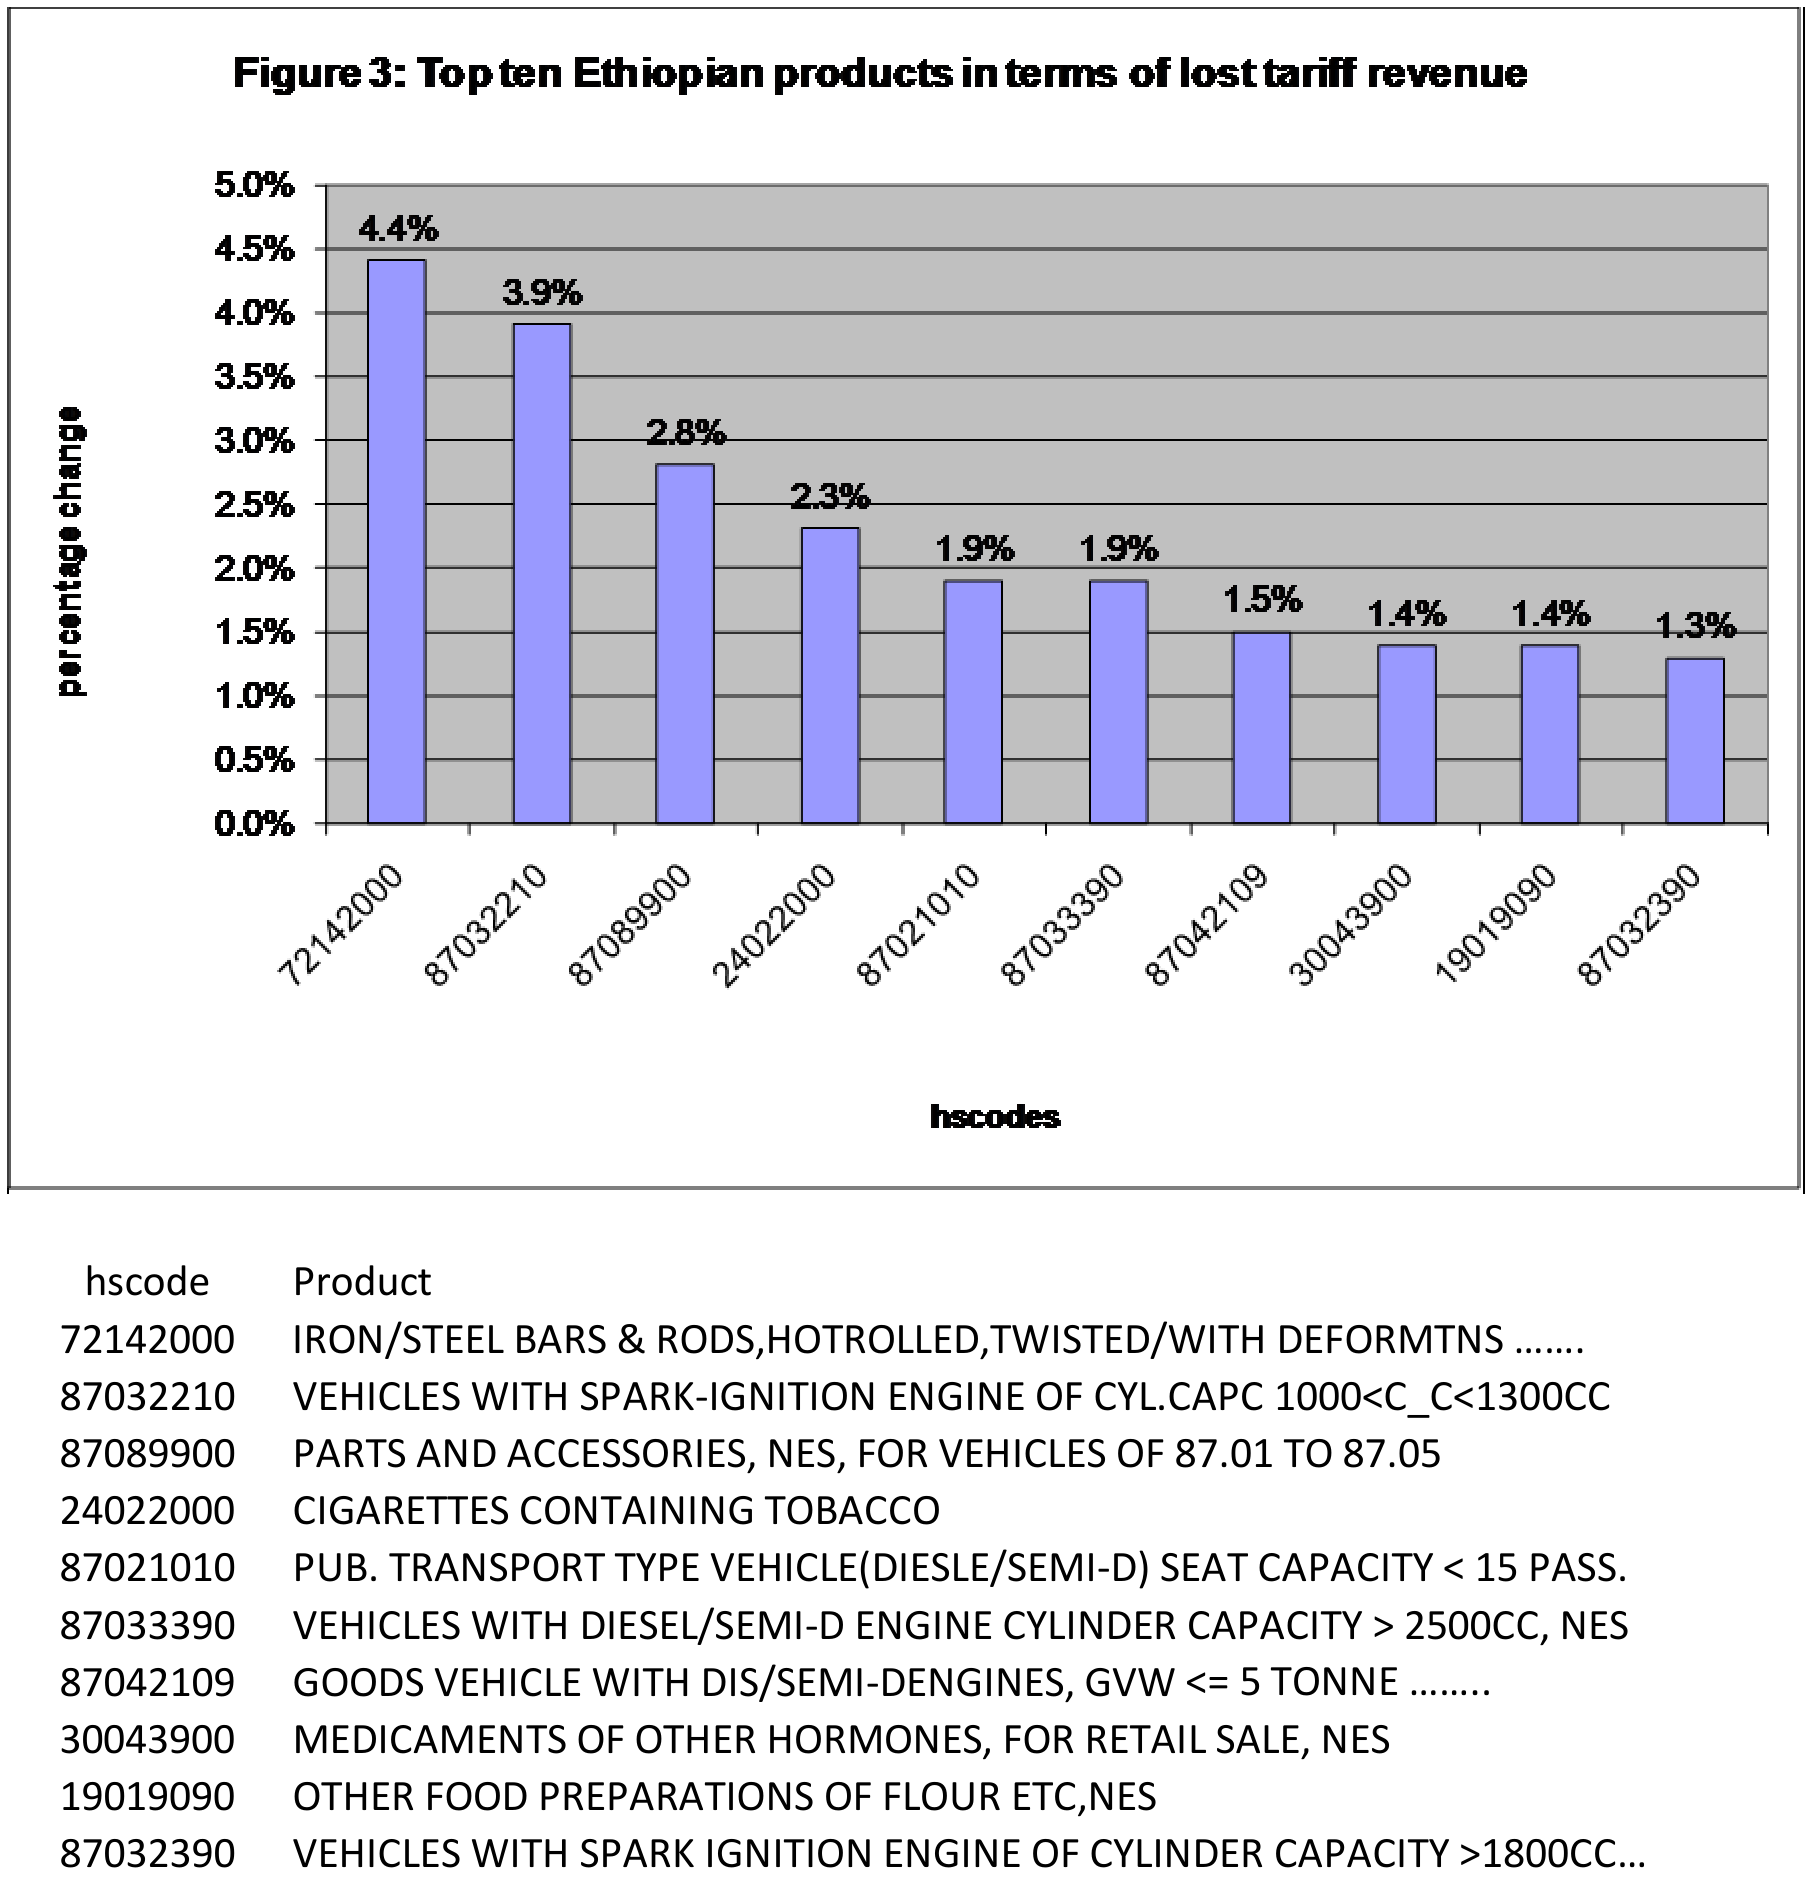

source,artifact_type,model,service_tier,elapsed_seconds,input_tokens,cached_input_tokens,output_tokens,cost_usd
prwp,figure,gpt-5.5,flex,39.7,"15,480",0,"3,329",$0.0886


#### Observations

,observation_id,fit_status,metadata_concept,closest_schema_fields,evidence_source,evidence,fit_rationale
0,obs_001,covered,Snapshot title and document-assigned figure identifier,"title, internal_identifier",snapshot,The snapshot heading reads “Figure 3: Top ten Ethiopian products in terms of lost tariff revenue.”,The existing title field captures the descriptive heading and internal_identifier captures “Figure 3” without loss.
1,obs_002,covered,Trade and tariff-revenue subject matter,"subject_domain, subject_summary",both,"The snapshot title refers to Ethiopian products and lost tariff revenue, and the source document title concerns trade policy changes using TRIST.",The existing subject fields can represent the broad trade-policy domain and summarize the figure’s analytical subject.
2,obs_003,covered,Geographic scope of the represented products,"geographic_scope, geographic_entities",snapshot,The snapshot title identifies the products as “Ethiopian products.”,The existing geographic fields can record Ethiopia as the explicit geographic scope/entity represented.
3,obs_004,covered,Measured variable and measurement form,"variable_name, unit_of_measure, measure_type",snapshot,The title names “lost tariff revenue” and the y-axis is labeled “percentage change” with percent tick labels.,"The existing fields can capture lost tariff revenue as the variable, percent as the unit, and percentage change as the measure form."
4,obs_005,covered,Product-code category dimension and labels,"category_dimension, category_labels",snapshot,"The x-axis is labeled “hscodes,” and the accompanying table lists columns “hscode” and “Product.”",The existing category fields can represent HS/product codes as the organizing dimension and the displayed codes and product names as labels.
5,obs_006,weak_fit,Top-N ranking and selection criterion,"title, subject_summary, variable_name, category_dimension",snapshot,The title states “Top ten Ethiopian products in terms of lost tariff revenue.”,"Existing fields can preserve the phrase or its components, but none structurally captures that the categories are a top-ten ranked selection by lost tariff revenue."
6,obs_007,covered,Visualization form,visualization_type,snapshot,The snapshot displays vertical bars for HS codes with percentage values and includes an accompanying product lookup table.,The visualization_type field can describe the artifact as a bar chart with an accompanying table/list.
7,obs_008,covered,Parent source document title,source_document_title,document,The source-document metadata title is “Assessing the adjustment implications of trade policy changes using TRIST (tariff reform impact simulation tool).”,The existing source_document_title field directly captures the parent document title.
8,obs_009,covered,Snapshot language,language,both,The snapshot text is in English and the document metadata lists language “english.”,The existing language field captures the language used in the snapshot.
9,obs_010,covered,Computational simulation tool used for the analysis,analysis_method,document,"The source document title names “TRIST (tariff reform impact simulation tool),” and the abstract says the paper describes the TRIST tool.",The analysis_method field can represent TRIST as the explicitly stated computational tool or method associated with the reported analysis.


#### Candidate fields

,proposed_name,definition,supporting_observation_ids,why_existing_fields_are_insufficient,operational_value,source_level
0,ranking_basis,"The explicit criterion, variable, or rule by which represented categories or entities are ranked, ordered, or selected, such as a top-N selection by a specified measure.",obs_006,"title and subject_summary can preserve the wording, while variable_name and category_dimension capture components, but none separately records the structured ranking or top-N selection logic.","Enables retrieval and comparison of snapshots that present ranked lists, top-N/bottom-N selections, or ordered categories by a specified criterion.",snapshot
1,source_document_locator,"A formal identifier, persistent link, catalog record identifier, or URL that enables retrieval or verification of the parent document containing the snapshot.",obs_011,source_document_title identifies the parent document by name but does not provide a machine-actionable or disambiguating locator such as a catalog ID or URL.,"Supports provenance verification, source retrieval, deduplication, and linkage back to the document from which a snapshot was extracted.",document


In [10]:
SNAPSHOT_INDEX = 0
inspect_result(results_df.iloc[SNAPSHOT_INDEX]["snapshot_file_name"])
